# UBCF Experiment Results Analysis

Bu notebook, UBCF (User-Based Collaborative Filtering) deney sonuçlarını görselleştirir.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Daha güzel grafikler
sns.set(style="whitegrid", font_scale=1.2)


## 1) CSV Dosyasını Yükle


In [10]:
# CSV dosyasını notebook ile aynı dizinde ara
BASE_DIR = os.getcwd()
# Eğer notebook farklı bir dizinde çalışıyorsa, dosya yolunu manuel olarak ayarlayın
csv_path = os.path.join(BASE_DIR, "ubcf_experiment_results.csv")
# Alternatif: Doğrudan dosya yolunu belirtin
# csv_path = "ubcf_experiment_results.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"\n[HATA] CSV dosyası bulunamadı!\n"
        f"Önce 'ubcf_experiment.py' çalıştırılmalı.\n"
        f"Aranan yer: {csv_path}"
    )

df = pd.read_csv(csv_path)

print("[INFO] Loaded:", df.shape, "rows")


[INFO] Loaded: (380, 7) rows


## En İyi Konfigürasyonlar (Detaylı Tablo)


In [17]:
# En iyi 20 konfigürasyonu seç (RMSE'ye göre sırala)
best_configs = df.sort_values("RMSE").head(20).copy()

# Sadece önemli kolonları seç ve düzenle
display_columns = ["similarity", "K_NEIGH", "K_PRED", "MIN_OVERLAP", "K_SW", "LAMBDA", "RMSE", "MAE", "Coverage"]
available_columns = [col for col in display_columns if col in best_configs.columns]

best_display = best_configs[available_columns].copy()

# Sıralama için index ekle
best_display.insert(0, "Rank", range(1, len(best_display) + 1))

# Sayısal değerleri formatla
if "RMSE" in best_display.columns:
    best_display["RMSE"] = best_display["RMSE"].round(4)
if "MAE" in best_display.columns:
    best_display["MAE"] = best_display["MAE"].round(4)
if "Coverage" in best_display.columns:
    best_display["Coverage"] = best_display["Coverage"].round(3)

print("=" * 100)
print("EN İYİ 20 UBCF KONFİGÜRASYONU (En Düşük RMSE)")
print("=" * 100)
print()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(best_display.to_string(index=False))
print()
print("=" * 100)


EN İYİ 20 UBCF KONFİGÜRASYONU (En Düşük RMSE)

 Rank     similarity  K_NEIGH  K_PRED  MIN_OVERLAP  K_SW  LAMBDA   RMSE    MAE  Coverage
    1 pearson_shrink       75      40          2.0   NaN    20.0 0.9502 0.7501       1.0
    2 pearson_shrink      100      40          2.0   NaN    20.0 0.9502 0.7501       1.0
    3 pearson_shrink       50      40          2.0   NaN    20.0 0.9502 0.7501       1.0
    4 pearson_shrink      100      40          2.0   NaN    10.0 0.9505 0.7506       1.0
    5 pearson_shrink       75      40          2.0   NaN    10.0 0.9505 0.7506       1.0
    6 pearson_shrink       50      40          2.0   NaN    10.0 0.9505 0.7506       1.0
    7 pearson_shrink      100      40          5.0   NaN    20.0 0.9506 0.7497       1.0
    8 pearson_shrink       50      40          5.0   NaN    20.0 0.9506 0.7497       1.0
    9 pearson_shrink       75      40          5.0   NaN    20.0 0.9506 0.7497       1.0
   10     pearson_sw       50      40          2.0  20.0     Na

In [21]:
# En iyi konfigürasyonu detaylı göster
best_config = df.sort_values("RMSE").iloc[0]

print("=" * 100)
print("🏆 EN İYİ KONFİGÜRASYON (En Düşük RMSE)")
print("=" * 100)
print()
print(f"Similarity Method    : {best_config['similarity']}")
print(f"K_NEIGH             : {best_config['K_NEIGH']}")
print(f"K_PRED              : {best_config['K_PRED']}")
if pd.notna(best_config.get('MIN_OVERLAP')):
    print(f"MIN_OVERLAP         : {best_config['MIN_OVERLAP']}")
if pd.notna(best_config.get('K_SW')):
    print(f"K_SW                : {best_config['K_SW']}")
if pd.notna(best_config.get('LAMBDA')):
    print(f"LAMBDA              : {best_config['LAMBDA']}")
print(f"RMSE                : {best_config['RMSE']:.4f}")
print(f"MAE                 : {best_config['MAE']:.4f}")
print(f"Coverage            : {best_config['Coverage']:.3f}")
print()
print("Tüm Parametreler:")
print(best_config['params'])
print()
print("=" * 100)


🏆 EN İYİ KONFİGÜRASYON (En Düşük RMSE)

Similarity Method    : pearson_shrink
K_NEIGH             : 75
K_PRED              : 40
MIN_OVERLAP         : 2.0
LAMBDA              : 20.0
RMSE                : 0.9502
MAE                 : 0.7501
Coverage            : 1.000

Tüm Parametreler:
{'MIN_OVERLAP': 2, 'LAMBDA': 20}



In [19]:
# Her similarity yöntemi için en iyi konfigürasyon
print("=" * 100)
print("HER SİMİLARİTY YÖNTEMİ İÇİN EN İYİ KONFİGÜRASYON")
print("=" * 100)
print()

for sim_method in df["similarity"].unique():
    sim_best = df[df["similarity"] == sim_method].sort_values("RMSE").iloc[0]
    print(f"\n📊 {sim_method.upper()}")
    print("-" * 80)
    print(f"  K_NEIGH      : {sim_best['K_NEIGH']}")
    print(f"  K_PRED       : {sim_best['K_PRED']}")
    if pd.notna(sim_best.get('MIN_OVERLAP')):
        print(f"  MIN_OVERLAP  : {sim_best['MIN_OVERLAP']}")
    if pd.notna(sim_best.get('K_SW')):
        print(f"  K_SW         : {sim_best['K_SW']}")
    if pd.notna(sim_best.get('LAMBDA')):
        print(f"  LAMBDA       : {sim_best['LAMBDA']}")
    print(f"  RMSE         : {sim_best['RMSE']:.4f}")
    print(f"  MAE          : {sim_best['MAE']:.4f}")
    print(f"  Coverage     : {sim_best['Coverage']:.3f}")

print()
print("=" * 100)


HER SİMİLARİTY YÖNTEMİ İÇİN EN İYİ KONFİGÜRASYON


📊 PEARSON_RAW
--------------------------------------------------------------------------------
  K_NEIGH      : 100
  K_PRED       : 40
  RMSE         : 0.9542
  MAE          : 0.7544
  Coverage     : 1.000

📊 PEARSON_SW
--------------------------------------------------------------------------------
  K_NEIGH      : 50
  K_PRED       : 40
  MIN_OVERLAP  : 2.0
  K_SW         : 20.0
  RMSE         : 0.9512
  MAE          : 0.7517
  Coverage     : 1.000

📊 PEARSON_SHRINK
--------------------------------------------------------------------------------
  K_NEIGH      : 50
  K_PRED       : 40
  MIN_OVERLAP  : 2.0
  LAMBDA       : 20.0
  RMSE         : 0.9502
  MAE          : 0.7501
  Coverage     : 1.000



## 2) Similarity Yöntemlerine Göre RMSE Kutu Grafiği


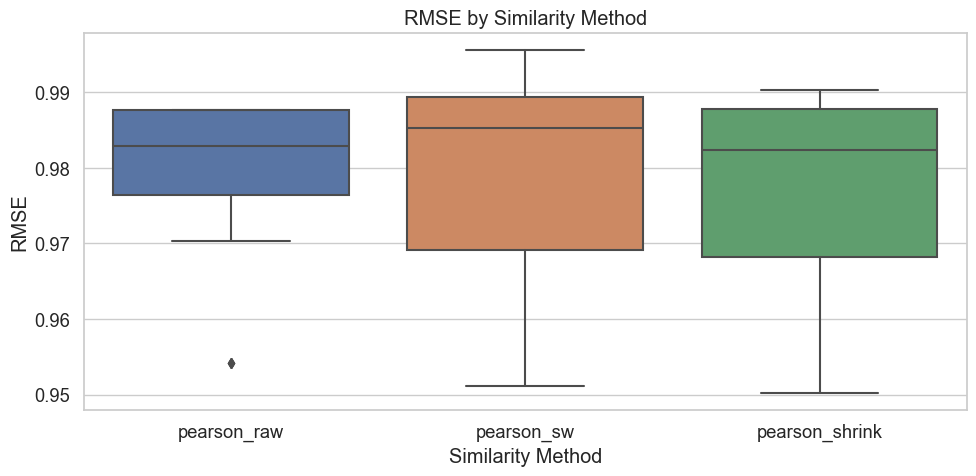

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="similarity", y="RMSE")
plt.title("RMSE by Similarity Method")
plt.ylabel("RMSE")
plt.xlabel("Similarity Method")
plt.tight_layout()
plt.show()


## 3) K_NEIGH → RMSE Eğrisi (Her Similarity İçin)


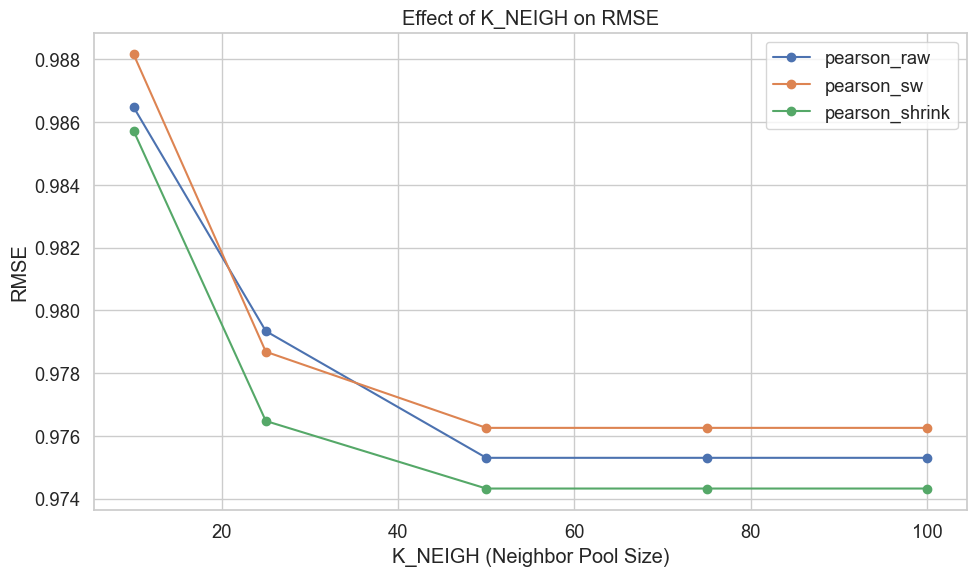

In [13]:
plt.figure(figsize=(10,6))
for sim in df["similarity"].unique():
    subset = df[df["similarity"] == sim]
    mean_vals = subset.groupby("K_NEIGH")["RMSE"].mean()
    plt.plot(mean_vals.index, mean_vals.values, marker="o", label=sim)

plt.title("Effect of K_NEIGH on RMSE")
plt.xlabel("K_NEIGH (Neighbor Pool Size)")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()


## 4) K_PRED → RMSE Eğrisi


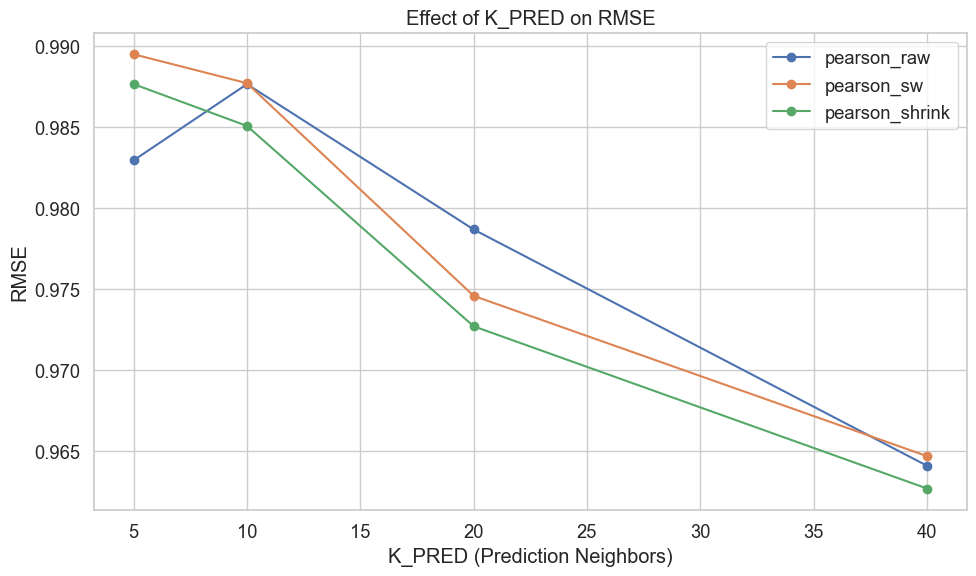

In [14]:
plt.figure(figsize=(10,6))
for sim in df["similarity"].unique():
    subset = df[df["similarity"] == sim]
    mean_vals = subset.groupby("K_PRED")["RMSE"].mean()
    plt.plot(mean_vals.index, mean_vals.values, marker="o", label=sim)

plt.title("Effect of K_PRED on RMSE")
plt.xlabel("K_PRED (Prediction Neighbors)")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()


## 5) Shrinkage Heatmap (LAMBDA vs MIN_OVERLAP)


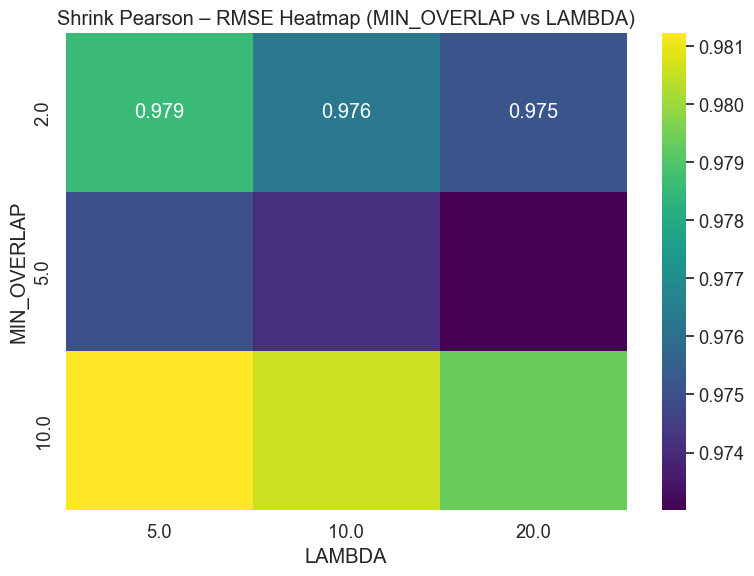

In [15]:
shrink_df = df[df["similarity"] == "pearson_shrink"]

# Heatmap pivot
pivot = shrink_df.pivot_table(
    index="MIN_OVERLAP",
    columns="LAMBDA",
    values="RMSE",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Shrink Pearson – RMSE Heatmap (MIN_OVERLAP vs LAMBDA)")
plt.ylabel("MIN_OVERLAP")
plt.xlabel("LAMBDA")
plt.tight_layout()
plt.show()


## 6) En İyi 20 Konfigürasyon – RMSE Bar Chart


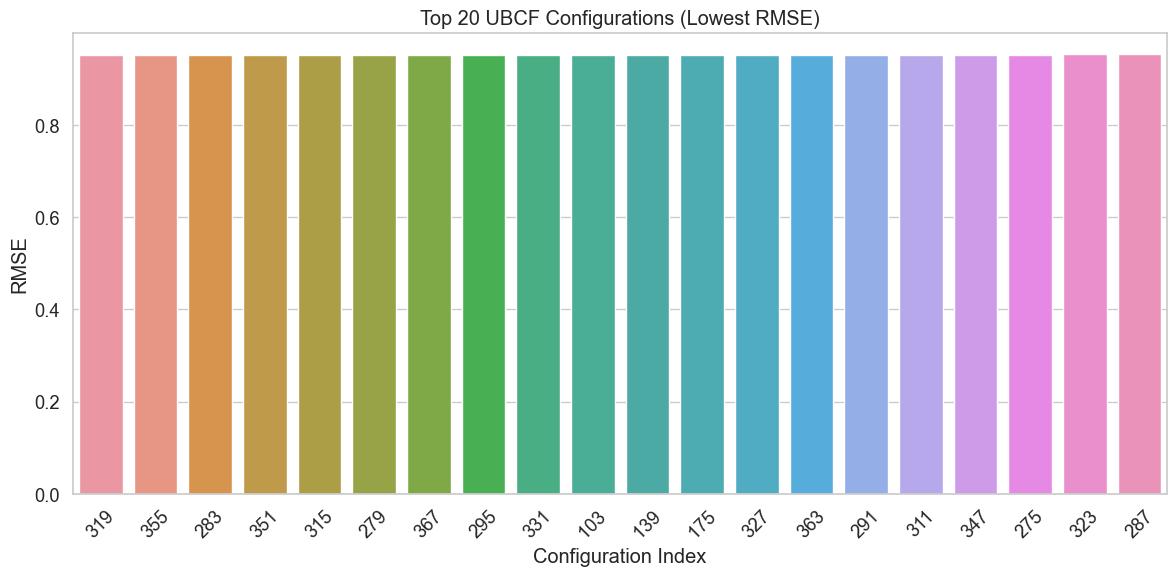

In [16]:
best = df.sort_values("RMSE").head(20)

plt.figure(figsize=(12,6))
sns.barplot(
    data=best,
    x=best.index.astype(str),
    y="RMSE"
)
plt.title("Top 20 UBCF Configurations (Lowest RMSE)")
plt.xlabel("Configuration Index")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
